# Model Training


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json

from pathlib import Path
from collections import Counter
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from imblearn.over_sampling import RandomOverSampler

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)


In [2]:
# Load label names from JSON file
def load_label_names():
    path = Path("../feature_engineering/label_mapping.json")
    if path.exists():
        with open(path) as f:
            cfg = json.load(f)
        return cfg.get("scenario_class_names", cfg.get("class_names", DEFAULT_SCENARIO_CLASS_NAMES))
    return DEFAULT_SCENARIO_CLASS_NAMES

# Consts
DEFAULT_SCENARIO_CLASS_NAMES = [
    "Botnet",
    "Miner",
    "Trojan-Agent",
    "Coinminer",
    "Cloud Attack",
    "Brute-Force",
    "Data-Caching",
    "Database",
    "Redis",
    "Web-Serving",
]

SCENARIO_CLASS_NAMES = load_label_names()
CLASS_NAMES = SCENARIO_CLASS_NAMES
METADATA_COLS = ["session_id", "pod_name", "namespace", "flow_window"]
TARGET_COLS = ["label", "scenario_label"]

## Load Dataset

In [3]:
syscall_df = pd.read_csv("../feature_engineering/dataset/syscall_dataset.csv")
network_df = pd.read_csv("../feature_engineering/dataset/network_flow_dataset.csv")

def load_label_rules():
    path = Path("../feature_engineering/label_mapping.json")
    if path.exists():
        with open(path) as f:
            cfg = json.load(f)
        return sorted(cfg["rules"], key=lambda rule: len(rule["pattern"]), reverse=True)
    return []

LABEL_RULES = load_label_rules()

def normalize_name(value):
    return (value or "").lower().replace("_", "-")

def infer_label_from_pod(pod_name):
    pod_lower = normalize_name(pod_name)
    for rule in LABEL_RULES:
        if normalize_name(rule["pattern"]) in pod_lower:
            return int(rule.get("scenario_label", rule.get("label")))
    return -1

def ensure_scenario_target(df):
    df = df.copy()

    if "scenario_label" not in df.columns:
        if "pod_name" in df.columns and LABEL_RULES:
            df["scenario_label"] = df["pod_name"].apply(infer_label_from_pod)
            unknown = df[df["scenario_label"] < 0]
            if not unknown.empty:
                print(f"Warning: dropping {len(unknown):,} rows with unknown pod labels")
                print(unknown["pod_name"].value_counts().head(15))
                df = df[df["scenario_label"] >= 0].copy()
        else:
            df["scenario_label"] = df["label"]

    df["label"] = df["scenario_label"]
    return df

syscall_df = ensure_scenario_target(syscall_df)
network_df = ensure_scenario_target(network_df)

print(f"Syscall dataset shape: {syscall_df.shape}")
print(f"Network dataset shape: {network_df.shape}")

print("\nSyscall sample:")
display(syscall_df.head())
print("\nNetwork sample:")
display(network_df.head())

Syscall dataset shape: (1262, 6)
Network dataset shape: (101898, 26)

Syscall sample:


,session_id,pod_name,namespace,label,scenario_label,ngram_doc
0,1,flask-postgres-59676499f7-qd4r5,benign-workloads,6,6,45_44_45_44_45 44_45_44_45_45 45_44_45_45_44 4...
1,1,flask-todo-f5887d88-lw42r,benign-workloads,8,8,257_257_257_257_257 257_257_257_257_257 257_25...
2,1,flask-todo-f5887d88-qgpgz,benign-workloads,8,8,257_257_257_257_257 257_257_257_257_257 257_25...
3,1,malicious-bruteforce-566c99886f-4np25,malicious,4,4,9_9_9_9_9 9_9_9_9_9 9_9_9_9_9 9_9_9_9_9 9_9_9_...
4,1,malicious-coinminer-7949c59578-cg64b,malicious,1,1,9_9_9_9_9 9_9_9_9_9 9_9_9_9_9 9_9_9_9_9 9_9_9_...



Network sample:


,session_id,pod_name,namespace,label,scenario_label,flow_window,unique_src_ports,unique_dst_ports,proto_TCP_count,proto_UDP_count,...,flag_SYN_count,flag_ACK_count,flag_RST_count,flag_PSH_count,is_well_known_port_count,is_high_port_count,is_dns_port_count,is_http_port_count,is_db_port_count,is_mining_port_count
0,1,flask-postgres-59676499f7-qd4r5,benign-workloads,6,6,0,1.0,2.0,7.0,0.0,...,0.0,7.0,0.0,7.0,0.0,5.0,0.0,0.0,0.0,0.0
1,1,flask-todo-f5887d88-lw42r,benign-workloads,8,8,0,1.0,34.0,100.0,0.0,...,34.0,100.0,0.0,33.0,0.0,100.0,0.0,0.0,0.0,0.0
2,1,flask-todo-f5887d88-lw42r,benign-workloads,8,8,1,2.0,34.0,100.0,0.0,...,32.0,100.0,0.0,35.0,0.0,26.0,0.0,0.0,2.0,0.0
3,1,flask-todo-f5887d88-lw42r,benign-workloads,8,8,2,1.0,25.0,75.0,0.0,...,25.0,75.0,0.0,25.0,0.0,75.0,0.0,0.0,0.0,0.0
4,1,flask-todo-f5887d88-qgpgz,benign-workloads,8,8,0,2.0,34.0,100.0,0.0,...,33.0,100.0,0.0,35.0,0.0,29.0,0.0,0.0,2.0,0.0


## Exploratory Data Analysis (EDA)

Label Distribution
Syscall scenario: {0: 3, 1: 114, 2: 32, 3: 23, 4: 50, 5: 82, 6: 308, 7: 169, 8: 481}
Network scenario: {0: 146, 1: 1358, 2: 1176, 3: 1756, 4: 18529, 5: 31215, 6: 4463, 7: 33762, 8: 9493}


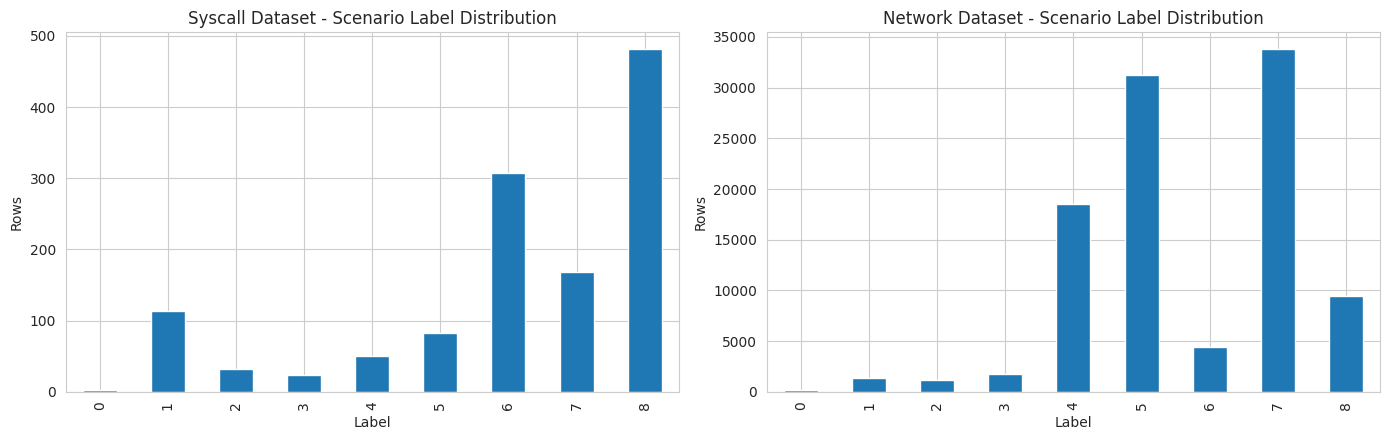

In [4]:
print("Label Distribution")
print("Syscall scenario:", syscall_df["scenario_label"].value_counts().sort_index().to_dict())
print("Network scenario:", network_df["scenario_label"].value_counts().sort_index().to_dict())

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
syscall_df["scenario_label"].value_counts().sort_index().plot(kind="bar", ax=axes[0])
axes[0].set_title("Syscall Dataset - Scenario Label Distribution")
network_df["scenario_label"].value_counts().sort_index().plot(kind="bar", ax=axes[1])
axes[1].set_title("Network Dataset - Scenario Label Distribution")
for ax in axes:
    ax.set_xlabel("Label")
    ax.set_ylabel("Rows")
plt.tight_layout()
plt.show()


## Data Preparation

In [5]:
def prepare_xy(df, target_col):
    drop_cols = [col for col in METADATA_COLS + TARGET_COLS if col in df.columns]
    X = df.drop(columns=drop_cols, errors="ignore")
    X = X.select_dtypes(include=[np.number]).fillna(0)
    y = df[target_col].astype(int)
    return X, y

def prepare_xy_syscall(df, target_col):
    """Prepare syscall features using CountVectorizer on ngram_doc column."""
    y = df[target_col].astype(int)
    if "ngram_doc" in df.columns:
        from sklearn.feature_extraction.text import CountVectorizer
        vec = CountVectorizer(token_pattern=r"[^ ]+", min_df=1)
        X_sparse = vec.fit_transform(df["ngram_doc"])
        X = pd.DataFrame(X_sparse.toarray(), columns=vec.get_feature_names_out(), index=df.index)
    else:
        drop_cols = [col for col in METADATA_COLS + TARGET_COLS if col in df.columns]
        X = df.drop(columns=drop_cols, errors="ignore")
        X = X.select_dtypes(include=[np.number]).fillna(0)
    return X, y

X_syscall, y_syscall = prepare_xy_syscall(syscall_df, "scenario_label")
X_network, y_network = prepare_xy(network_df, "scenario_label")

print(f"Syscall features: {X_syscall.shape}")
print(f"Network features: {X_network.shape}")
print(f"Syscall feature columns: {X_syscall.columns.tolist()}")
print(f"Network feature columns: {X_network.columns.tolist()}")


Syscall features: (1262, 6168)
Network features: (101898, 20)
Syscall feature columns: ['10_10_10_10_10', '10_10_10_10_12', '10_10_10_10_231', '10_10_10_10_257', '10_10_10_10_281', '10_10_10_10_41', '10_10_10_10_44', '10_10_10_10_9', '10_10_10_12_12', '10_10_10_12_257', '10_10_10_12_281', '10_10_10_12_9', '10_10_10_16_12', '10_10_10_16_9', '10_10_10_231_231', '10_10_10_231_59', '10_10_10_231_9', '10_10_10_257_10', '10_10_10_257_16', '10_10_10_257_257', '10_10_10_257_9', '10_10_10_281_10', '10_10_10_281_281', '10_10_10_281_9', '10_10_10_41_42', '10_10_10_43_44', '10_10_10_44_45', '10_10_10_59_12', '10_10_10_59_9', '10_10_10_9_10', '10_10_10_9_12', '10_10_10_9_16', '10_10_10_9_231', '10_10_10_9_257', '10_10_10_9_281', '10_10_10_9_41', '10_10_10_9_42', '10_10_10_9_59', '10_10_10_9_9', '10_10_12_12_12', '10_10_12_12_16', '10_10_12_12_257', '10_10_12_12_41', '10_10_12_12_9', '10_10_12_257_257', '10_10_12_257_9', '10_10_12_281_281', '10_10_12_9_10', '10_10_12_9_9', '10_10_16_10_12', '10_10_1

In [6]:
def split_dataset(df, X, y, name):
    groups = df.loc[X.index, "session_id"]
    n_groups = groups.nunique()
    if n_groups > 1:
        gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
        train_idx, test_idx = next(gss.split(X, y, groups=groups))
        train_groups = set(groups.iloc[train_idx])
        test_groups  = set(groups.iloc[test_idx])
        assert not (train_groups & test_groups), "Session leakage detected!"
        split_by = "session_id"
    else:
        # Fallback: split by pod_name to prevent same-pod leakage
        groups = df.loc[X.index, "pod_name"]
        gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
        train_idx, test_idx = next(gss.split(X, y, groups=groups))
        split_by = "pod_name"
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    print(f"{name} split: GroupShuffleSplit by {split_by} (no leakage)")
    print(f"{name} - Train: {X_train.shape}, Test: {X_test.shape}")
    print(f"{name} train labels: {Counter(y_train)}")
    print(f"{name} test labels : {Counter(y_test)}")
    return X_train, X_test, y_train, y_test

X_train_sys, X_test_sys, y_train_sys, y_test_sys = split_dataset(
    syscall_df, X_syscall, y_syscall, "Syscall Scenario"
)
X_train_net, X_test_net, y_train_net, y_test_net = split_dataset(
    network_df, X_network, y_network, "Network Scenario"
)

# Re-apply SelectKBest only on train to avoid feature selection leakage
from sklearn.feature_selection import SelectKBest, chi2
selector_net = SelectKBest(chi2, k=min(20, X_train_net.shape[1]))
X_train_net = pd.DataFrame(
    selector_net.fit_transform(X_train_net.abs(), y_train_net),
    columns=X_train_net.columns[selector_net.get_support()]
)
X_test_net = pd.DataFrame(
    selector_net.transform(X_test_net.abs()),
    columns=X_train_net.columns
)
print(f"Network features after train-only selection: {X_train_net.columns.tolist()}")


Syscall Scenario split: GroupShuffleSplit by session_id (no leakage)
Syscall Scenario - Train: (877, 6168), Test: (385, 6168)
Syscall Scenario train labels: Counter({8: 339, 6: 216, 7: 116, 1: 73, 5: 57, 4: 36, 2: 23, 3: 15, 0: 2})
Syscall Scenario test labels : Counter({8: 142, 6: 92, 7: 53, 1: 41, 5: 25, 4: 14, 2: 9, 3: 8, 0: 1})
Network Scenario split: GroupShuffleSplit by session_id (no leakage)
Network Scenario - Train: (70409, 20), Test: (31489, 20)
Network Scenario train labels: Counter({7: 23457, 5: 21984, 4: 12290, 8: 6495, 6: 3095, 3: 1167, 1: 985, 2: 824, 0: 112})
Network Scenario test labels : Counter({7: 10305, 5: 9231, 4: 6239, 8: 2998, 6: 1368, 3: 589, 1: 373, 2: 352, 0: 34})
Network features after train-only selection: ['unique_src_ports', 'unique_dst_ports', 'proto_TCP_count', 'proto_UDP_count', 'proto_OTHER_count', 'dir_EGRESS_count', 'dir_INGRESS_count', 'verdict_FORWARDED_count', 'verdict_DROPPED_count', 'verdict_TRACED_count', 'flag_SYN_count', 'flag_ACK_count', 'f

## Class Balancing

In [7]:
def balance_training_data(X_train, y_train, name, max_growth=5, max_majority_ratio=0.5):
    counts = pd.Series(y_train).value_counts().sort_index()
    print(f"{name} - Before balancing: {counts.to_dict()}")

    if len(counts) < 2:
        print(f"{name} - Skipped: only one class present.")
        return X_train, y_train

    majority = int(counts.max())
    ratio_cap = max(1, int(majority * max_majority_ratio))
    sampling_strategy = {}
    for label, count in counts.items():
        count = int(count)
        target = min(majority, ratio_cap, count * max_growth)
        sampling_strategy[int(label)] = max(count, target)

    sampler = RandomOverSampler(sampling_strategy=sampling_strategy, random_state=42)
    X_balanced, y_balanced = sampler.fit_resample(X_train, y_train)
    print(f"{name} - Sampling strategy: {sampling_strategy}")
    print(f"{name} - After balancing: {pd.Series(y_balanced).value_counts().sort_index().to_dict()}")
    return X_balanced, y_balanced

X_train_sys_balanced, y_train_sys_balanced = balance_training_data(X_train_sys, y_train_sys, "Syscall Scenario")
X_train_net_balanced, y_train_net_balanced = balance_training_data(X_train_net, y_train_net, "Network Scenario")


Syscall Scenario - Before balancing: {0: 2, 1: 73, 2: 23, 3: 15, 4: 36, 5: 57, 6: 216, 7: 116, 8: 339}
Syscall Scenario - Sampling strategy: {0: 10, 1: 169, 2: 115, 3: 75, 4: 169, 5: 169, 6: 216, 7: 169, 8: 339}
Syscall Scenario - After balancing: {0: 10, 1: 169, 2: 115, 3: 75, 4: 169, 5: 169, 6: 216, 7: 169, 8: 339}
Network Scenario - Before balancing: {0: 112, 1: 985, 2: 824, 3: 1167, 4: 12290, 5: 21984, 6: 3095, 7: 23457, 8: 6495}
Network Scenario - Sampling strategy: {0: 560, 1: 4925, 2: 4120, 3: 5835, 4: 12290, 5: 21984, 6: 11728, 7: 23457, 8: 11728}
Network Scenario - After balancing: {0: 560, 1: 4925, 2: 4120, 3: 5835, 4: 12290, 5: 21984, 6: 11728, 7: 23457, 8: 11728}


## Train Decision Tree Model

In [8]:
def make_dt():
    return DecisionTreeClassifier(
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        criterion="gini",
        # class_weight="balanced",
        random_state=42,
    )

dt_syscall = make_dt()
dt_network = make_dt()

print("Training scenario syscall model...")
dt_syscall.fit(X_train_sys_balanced, y_train_sys_balanced)
print("Training scenario network model...")
dt_network.fit(X_train_net_balanced, y_train_net_balanced)
print("Scenario models trained")


Training scenario syscall model...
Training scenario network model...
Scenario models trained


## Model Evaluation

In [9]:
def class_names_for_labels(labels, class_names):
    labels = sorted(pd.Series(labels).dropna().astype(int).unique())
    names = [class_names[i] if 0 <= i < len(class_names) else str(i) for i in labels]
    return labels, names

def evaluate_model(model, X_test, y_test, name, class_names):
    y_pred = model.predict(X_test)
    labels, names = class_names_for_labels(pd.concat([pd.Series(y_test), pd.Series(y_pred)]), class_names)

    print(f"--- {name} ---")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(classification_report(
        y_test,
        y_pred,
        labels=labels,
        target_names=names,
        zero_division=0,
    ))
    return y_pred, labels, names

y_pred_sys, sys_labels, sys_names = evaluate_model(
    dt_syscall, X_test_sys, y_test_sys, "SYSCALL SCENARIO CLASSIFICATION", SCENARIO_CLASS_NAMES
)
y_pred_net, net_labels, net_names = evaluate_model(
    dt_network, X_test_net, y_test_net, "NETWORK SCENARIO CLASSIFICATION", SCENARIO_CLASS_NAMES
)


--- SYSCALL SCENARIO CLASSIFICATION ---
Accuracy: 0.9610
              precision    recall  f1-score   support

      Botnet       0.00      0.00      0.00         1
 Cryptominer       0.86      0.93      0.89        41
Trojan-Agent       0.90      1.00      0.95         9
Cloud Attack       1.00      0.75      0.86         8
 Brute-Force       0.92      0.79      0.85        14
Data-Caching       1.00      0.96      0.98        25
    Database       0.98      1.00      0.99        92
       Redis       1.00      0.98      0.99        53
 Web-Serving       0.97      0.97      0.97       142

    accuracy                           0.96       385
   macro avg       0.85      0.82      0.83       385
weighted avg       0.96      0.96      0.96       385

--- NETWORK SCENARIO CLASSIFICATION ---
Accuracy: 0.9137
              precision    recall  f1-score   support

      Botnet       0.94      1.00      0.97        34
 Cryptominer       0.84      0.33      0.47       373
Trojan-Agent      

In [10]:
def per_class_support(y_true, y_pred, class_names, name):
    labels, names = class_names_for_labels(pd.concat([pd.Series(y_true), pd.Series(y_pred)]), class_names)
    report = classification_report(
        y_true,
        y_pred,
        labels=labels,
        target_names=names,
        zero_division=0,
        output_dict=True,
    )
    rows = []
    for label, class_name in zip(labels, names):
        metrics = report[class_name]
        rows.append({
            "label": label,
            "class_name": class_name,
            "precision": metrics["precision"],
            "recall": metrics["recall"],
            "f1_score": metrics["f1-score"],
            "support": int(metrics["support"]),
        })
    df = pd.DataFrame(rows)
    print(f"{name} per-class metrics")
    display(df)
    return df

syscall_class_metrics = per_class_support(
    y_test_sys, y_pred_sys, SCENARIO_CLASS_NAMES, "Syscall scenario"
)
network_class_metrics = per_class_support(
    y_test_net, y_pred_net, SCENARIO_CLASS_NAMES, "Network scenario"
)


Syscall scenario per-class metrics


,label,class_name,precision,recall,f1_score,support
0,0,Botnet,0.000000,0.000000,0.000000,1
1,1,Cryptominer,0.863636,0.926829,0.894118,41
2,2,Trojan-Agent,0.900000,1.000000,0.947368,9
3,3,Cloud Attack,1.000000,0.750000,0.857143,8
4,4,Brute-Force,0.916667,0.785714,0.846154,14
5,5,Data-Caching,1.000000,0.960000,0.979592,25
6,6,Database,0.978723,1.000000,0.989247,92
7,7,Redis,1.000000,0.981132,0.990476,53
8,8,Web-Serving,0.965035,0.971831,0.968421,142


Network scenario per-class metrics


,label,class_name,precision,recall,f1_score,support
0,0,Botnet,0.944444,1.000000,0.971429,34
1,1,Cryptominer,0.841379,0.327078,0.471042,373
2,2,Trojan-Agent,0.985755,0.982955,0.984353,352
3,3,Cloud Attack,0.930582,0.842105,0.884135,589
4,4,Brute-Force,0.998235,0.997275,0.997755,6239
5,5,Data-Caching,0.875783,0.893619,0.884611,9231
6,6,Database,0.398929,0.653509,0.495428,1368
7,7,Redis,0.989444,0.991460,0.990451,10305
8,8,Web-Serving,0.993197,0.730487,0.841822,2998


In [11]:
# Extract TP, TN, FP, FN from binary confusion matrices
def extract_binary_metrics(y_true, y_pred, name):
    def safe_div(num, den):
        return num / den if den else 0.0

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    total = tn + fp + fn + tp
    print(f"{'='*60}")
    print(f"{name}")
    print(f"{'='*60}")
    print()
    print(f"{'Prediction Breakdown':^60}")
    print(f"{'-'*60}")
    print(f"{'':20}{'Pred Benign':>15}{'Pred Malicious':>15}{'Total':>10}")
    print(f"{'-'*60}")
    print(f"{'Actual Benign':<20}{tn:>15,}{fp:>15,}{tn+fp:>10,}")
    print(f"{'Actual Malicious':<20}{fn:>15,}{tp:>15,}{fn+tp:>10,}")
    print(f"{'-'*60}")
    print(f"{'Total':<20}{tn+fn:>15,}{fp+tp:>15,}{total:>10,}")
    print()
    print(f"{'Metrics':^60}")
    print(f"{'-'*60}")
    print(f"Accuracy:  {safe_div(tp + tn, total):.4f}")
    print(f"Precision: {safe_div(tp, tp + fp):.4f}")
    print(f"Recall:    {safe_div(tp, tp + fn):.4f}")
    print(f"FPR:       {safe_div(fp, fp + tn):.4f}")
    print(f"FNR:       {safe_div(fn, fn + tp):.4f}")
    print(f"F1-Score:  {safe_div(2 * tp, 2 * tp + fp + fn):.4f}")
    print()
    return {"tn": tn, "fp": fp, "fn": fn, "tp": tp}

def extract_multiclass_metrics(y_true, y_pred, class_names, name):
    from sklearn.metrics import classification_report, accuracy_score
    labels = sorted(set(y_true) | set(y_pred))
    names = [class_names[i] for i in labels if i < len(class_names)]
    print(f"{'='*60}")
    print(f"{name}")
    print(f"{'='*60}")
    print(classification_report(y_true, y_pred, labels=labels, target_names=names, digits=4, zero_division=0))

# Convert scenario labels to binary (benign=0 for labels>=4, malicious=1 for labels<4)
def to_binary(y):
    return (pd.Series(y).map(lambda x: 0 if x >= 5 else 1)).values

y_test_sys_bin = to_binary(y_test_sys)
y_pred_sys_bin = to_binary(y_pred_sys)
y_test_net_bin = to_binary(y_test_net)
y_pred_net_bin = to_binary(y_pred_net)

# Binary metrics
syscall_binary_metrics = extract_binary_metrics(
    y_test_sys_bin, y_pred_sys_bin, "SYSCALL BINARY - TP/TN/FP/FN"
)
network_binary_metrics = extract_binary_metrics(
    y_test_net_bin, y_pred_net_bin, "NETWORK BINARY - TP/TN/FP/FN"
)

# Multiclass metrics
extract_multiclass_metrics(y_test_sys, y_pred_sys, SCENARIO_CLASS_NAMES, "SYSCALL SCENARIO - Per-Class Metrics")
extract_multiclass_metrics(y_test_net, y_pred_net, SCENARIO_CLASS_NAMES, "NETWORK SCENARIO - Per-Class Metrics")


SYSCALL BINARY - TP/TN/FP/FN

                    Prediction Breakdown                    
------------------------------------------------------------
                        Pred Benign Pred Malicious     Total
------------------------------------------------------------
Actual Benign                   308              4       312
Actual Malicious                  5             68        73
------------------------------------------------------------
Total                           313             72       385

                          Metrics                           
------------------------------------------------------------
Accuracy:  0.9766
Precision: 0.9444
Recall:    0.9315
FPR:       0.0128
FNR:       0.0685
F1-Score:  0.9379

NETWORK BINARY - TP/TN/FP/FN

                    Prediction Breakdown                    
------------------------------------------------------------
                        Pred Benign Pred Malicious     Total
-------------------------------------

In [12]:
# CReate test: with 4:6 samples

MALICIOUS_LABELS = {0, 1, 2, 3, 4, 5}

def robustness_test_4_6(model, X_test, y_test, model_name, total_samples=10):
    y_test_arr = np.array(y_test.reset_index(drop=True))
    X_test_reset = X_test.reset_index(drop=True)
    X_test_arr = X_test_reset.values
    feat_cols  = X_test_reset.columns.tolist()

    benign_idx    = np.where(~np.isin(y_test_arr, list(MALICIOUS_LABELS)))[0]
    malicious_idx = np.where( np.isin(y_test_arr, list(MALICIOUS_LABELS)))[0]

    if np.random.rand() > 0.5:
        n_benign, n_malicious = 4, 6
    else:
        n_benign, n_malicious = 6, 4

    sampled_b   = np.random.choice(benign_idx,    n_benign,    replace=False)
    sampled_m   = np.random.choice(malicious_idx, n_malicious, replace=False)
    sampled_idx = np.concatenate([sampled_b, sampled_m])
    np.random.shuffle(sampled_idx)

    X_sample    = X_test_arr[sampled_idx]
    y_true_scen = y_test_arr[sampled_idx]
    y_true_bin  = np.isin(y_true_scen, list(MALICIOUS_LABELS)).astype(int)
    y_pred_scen = model.predict(X_sample)
    y_pred_bin  = np.isin(y_pred_scen, list(MALICIOUS_LABELS)).astype(int)

    rows = []
    for j in range(len(sampled_idx)):
        actual_name = SCENARIO_CLASS_NAMES[y_true_scen[j]] if y_true_scen[j] < len(SCENARIO_CLASS_NAMES) else str(y_true_scen[j])
        pred_name   = SCENARIO_CLASS_NAMES[y_pred_scen[j]] if y_pred_scen[j] < len(SCENARIO_CLASS_NAMES) else str(y_pred_scen[j])
        actual_bin  = "Malicious" if y_true_bin[j] == 1 else "Benign"
        pred_bin    = "Malicious" if y_pred_bin[j] == 1 else "Benign"

        if   y_true_bin[j] == 1 and y_pred_bin[j] == 1: verdict = "TP"
        elif y_true_bin[j] == 0 and y_pred_bin[j] == 0: verdict = "TN"
        elif y_true_bin[j] == 0 and y_pred_bin[j] == 1: verdict = "FP"
        else:                                             verdict = "FN"

        row = {
            "#": j + 1,
            "actual_scenario": actual_name,
            "actual_label": y_true_scen[j],
            "actual_type": actual_bin,
            "pred_scenario": pred_name,
            "pred_label": y_pred_scen[j],
            "pred_type": pred_bin,
            "verdict": verdict,
        }
        for k, col in enumerate(feat_cols):
            row[col] = round(float(X_sample[j][k]), 4)
        rows.append(row)

    df_sample = pd.DataFrame(rows)

    tp = int(np.sum((y_true_bin == 1) & (y_pred_bin == 1)))
    tn = int(np.sum((y_true_bin == 0) & (y_pred_bin == 0)))
    fp = int(np.sum((y_true_bin == 0) & (y_pred_bin == 1)))
    fn = int(np.sum((y_true_bin == 1) & (y_pred_bin == 0)))
    acc  = (tp + tn) / total_samples
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0

    print(f"{'='*80}")
    print(f"ROBUSTNESS TEST -- {model_name}")
    print(f"Ratio Benign:Malicious = {n_benign}:{n_malicious}  (n={total_samples})")
    print(f"{'='*80}")
    display(df_sample)
    print(f"TP={tp}  TN={tn}  FP={fp}  FN={fn}  |  Acc={acc:.2f}  Prec={prec:.2f}  Recall={rec:.2f}  F1={f1:.2f}")

np.random.seed(42)
robustness_test_4_6(dt_syscall, X_test_sys, y_test_sys, "SYSCALL MODEL")
print()
robustness_test_4_6(dt_network, X_test_net, y_test_net, "NETWORK MODEL")


ROBUSTNESS TEST -- SYSCALL MODEL
Ratio Benign:Malicious = 6:4  (n=10)


,#,actual_scenario,actual_label,actual_type,pred_scenario,pred_label,pred_type,verdict,10_10_10_10_10,10_10_10_10_12,...,9_9_9_9_257,9_9_9_9_281,9_9_9_9_35,9_9_9_9_41,9_9_9_9_42,9_9_9_9_44,9_9_9_9_45,9_9_9_9_56,9_9_9_9_59,9_9_9_9_9
0,1,Database,6,Benign,Database,6,Benign,TN,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,Web-Serving,8,Benign,Web-Serving,8,Benign,TN,20.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,122.0
2,3,Data-Caching,5,Malicious,Data-Caching,5,Malicious,TP,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,Database,6,Benign,Database,6,Benign,TN,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,Redis,7,Benign,Redis,7,Benign,TN,0.0,0.0,...,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1382.0
5,6,Database,6,Benign,Database,6,Benign,TN,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,7,Data-Caching,5,Malicious,Data-Caching,5,Malicious,TP,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,8,Cryptominer,1,Malicious,Cryptominer,1,Malicious,TP,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,9,Cryptominer,1,Malicious,Cryptominer,1,Malicious,TP,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,191.0
9,10,Database,6,Benign,Database,6,Benign,TN,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


TP=4  TN=6  FP=0  FN=0  |  Acc=1.00  Prec=1.00  Recall=1.00  F1=1.00

ROBUSTNESS TEST -- NETWORK MODEL
Ratio Benign:Malicious = 4:6  (n=10)


,#,actual_scenario,actual_label,actual_type,pred_scenario,pred_label,pred_type,verdict,unique_src_ports,unique_dst_ports,...,flag_SYN_count,flag_ACK_count,flag_RST_count,flag_PSH_count,is_well_known_port_count,is_high_port_count,is_dns_port_count,is_http_port_count,is_db_port_count,is_mining_port_count
0,1,Brute-Force,4,Malicious,Brute-Force,4,Malicious,TP,10.0,10.0,...,0.0,0.0,0.0,0.0,8.0,3.0,8.0,0.0,0.0,0.0
1,2,Data-Caching,5,Malicious,Data-Caching,5,Malicious,TP,11.0,8.0,...,4.0,16.0,0.0,4.0,20.0,4.0,20.0,0.0,28.0,0.0
2,3,Web-Serving,8,Benign,Web-Serving,8,Benign,TN,14.0,15.0,...,0.0,0.0,0.0,0.0,13.0,4.0,13.0,0.0,0.0,0.0
3,4,Redis,7,Benign,Redis,7,Benign,TN,15.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,Brute-Force,4,Malicious,Brute-Force,4,Malicious,TP,8.0,6.0,...,3.0,9.0,0.0,3.0,9.0,2.0,9.0,0.0,0.0,0.0
5,6,Redis,7,Benign,Redis,7,Benign,TN,12.0,9.0,...,8.0,24.0,0.0,8.0,0.0,24.0,0.0,0.0,0.0,0.0
6,7,Web-Serving,8,Benign,Web-Serving,8,Benign,TN,9.0,8.0,...,3.0,12.0,0.0,3.0,37.0,3.0,10.0,27.0,0.0,0.0
7,8,Brute-Force,4,Malicious,Brute-Force,4,Malicious,TP,5.0,6.0,...,6.0,24.0,0.0,6.0,17.0,10.0,0.0,0.0,0.0,0.0
8,9,Data-Caching,5,Malicious,Data-Caching,5,Malicious,TP,26.0,27.0,...,0.0,0.0,0.0,0.0,25.0,12.0,25.0,0.0,0.0,0.0
9,10,Brute-Force,4,Malicious,Brute-Force,4,Malicious,TP,10.0,10.0,...,0.0,0.0,0.0,0.0,8.0,2.0,8.0,0.0,0.0,0.0


TP=6  TN=4  FP=0  FN=0  |  Acc=1.00  Prec=1.00  Recall=1.00  F1=1.00


In [13]:
# Ensemble: Syscall + Network Combined Prediction
def ensemble_test(syscall_model, network_model,
                  X_test_sys, y_test_sys,
                  X_test_net, y_test_net,
                  total_samples=10):

    y_sys = np.array(y_test_sys.reset_index(drop=True))
    y_net = np.array(y_test_net.reset_index(drop=True))
    X_sys = X_test_sys.reset_index(drop=True).values
    X_net = X_test_net.reset_index(drop=True).values

    y_sys_bin = np.isin(y_sys, list(MALICIOUS_LABELS)).astype(int)
    y_net_bin = np.isin(y_net, list(MALICIOUS_LABELS)).astype(int)

    # Predict on full test sets
    y_pred_sys_scen = syscall_model.predict(X_sys)
    y_pred_net_scen = network_model.predict(X_net)
    y_pred_sys_bin  = np.isin(y_pred_sys_scen, list(MALICIOUS_LABELS)).astype(int)
    y_pred_net_bin  = np.isin(y_pred_net_scen, list(MALICIOUS_LABELS)).astype(int)

    # Sample 10 labels that exist in BOTH test sets
    sys_labels  = set(y_sys)
    net_labels  = set(y_net)
    common_labels = sorted(sys_labels & net_labels)

    if np.random.rand() > 0.5:
        n_benign, n_malicious = 4, 6
    else:
        n_benign, n_malicious = 6, 4

    benign_labels    = [l for l in common_labels if l not in MALICIOUS_LABELS]
    malicious_labels = [l for l in common_labels if l in MALICIOUS_LABELS]

    def sample_label_idx(y_arr, labels, n):
        idx_pool = np.where(np.isin(y_arr, labels))[0]
        return np.random.choice(idx_pool, min(n, len(idx_pool)), replace=False)

    # Sample syscall and network indices with matching label distribution
    sys_b_idx = sample_label_idx(y_sys, benign_labels,    n_benign)
    sys_m_idx = sample_label_idx(y_sys, malicious_labels, n_malicious)
    net_b_idx = sample_label_idx(y_net, benign_labels,    n_benign)
    net_m_idx = sample_label_idx(y_net, malicious_labels, n_malicious)

    s_idx = np.concatenate([sys_b_idx, sys_m_idx])
    n_idx = np.concatenate([net_b_idx, net_m_idx])

    # Shuffle both with same permutation so row i has same ground truth type
    perm = np.random.permutation(len(s_idx))
    s_idx = s_idx[perm]
    n_idx = n_idx[perm]

    y_true     = y_sys_bin[s_idx]
    pred_sys   = y_pred_sys_bin[s_idx]
    pred_net   = y_pred_net_bin[n_idx]
    pred_AND   = (pred_sys & pred_net).astype(int)
    pred_OR    = (pred_sys | pred_net).astype(int)

    rows = []
    for j in range(len(s_idx)):
        actual_type   = "Malicious" if y_true[j] == 1 else "Benign"
        scen_s = SCENARIO_CLASS_NAMES[y_sys[s_idx[j]]] if y_sys[s_idx[j]] < len(SCENARIO_CLASS_NAMES) else str(y_sys[s_idx[j]])
        pred_s = SCENARIO_CLASS_NAMES[y_pred_sys_scen[s_idx[j]]] if y_pred_sys_scen[s_idx[j]] < len(SCENARIO_CLASS_NAMES) else str(y_pred_sys_scen[s_idx[j]])
        scen_n = SCENARIO_CLASS_NAMES[y_net[n_idx[j]]] if y_net[n_idx[j]] < len(SCENARIO_CLASS_NAMES) else str(y_net[n_idx[j]])
        pred_n = SCENARIO_CLASS_NAMES[y_pred_net_scen[n_idx[j]]] if y_pred_net_scen[n_idx[j]] < len(SCENARIO_CLASS_NAMES) else str(y_pred_net_scen[n_idx[j]])

        def vd(yt, yp):
            if yt==1 and yp==1: return "TP"
            if yt==0 and yp==0: return "TN"
            if yt==0 and yp==1: return "FP"
            return "FN"

        rows.append({
            "#": j+1,
            "actual_type": actual_type,
            "syscall_scenario": scen_s,
            "syscall_pred": pred_s,
            "sys_verdict": vd(y_true[j], pred_sys[j]),
            "network_scenario": scen_n,
            "network_pred": pred_n,
            "net_verdict": vd(y_true[j], pred_net[j]),
            "AND_pred": "Malicious" if pred_AND[j]==1 else "Benign",
            "AND_verdict": vd(y_true[j], pred_AND[j]),
            "OR_pred": "Malicious" if pred_OR[j]==1 else "Benign",
            "OR_verdict": vd(y_true[j], pred_OR[j]),
        })

    df = pd.DataFrame(rows)

    def metrics(y_true, y_pred, name):
        tp = int(np.sum((y_true==1)&(y_pred==1)))
        tn = int(np.sum((y_true==0)&(y_pred==0)))
        fp = int(np.sum((y_true==0)&(y_pred==1)))
        fn = int(np.sum((y_true==1)&(y_pred==0)))
        n  = len(y_true)
        acc  = (tp+tn)/n
        prec = tp/(tp+fp) if (tp+fp)>0 else 0
        rec  = tp/(tp+fn) if (tp+fn)>0 else 0
        f1   = 2*prec*rec/(prec+rec) if (prec+rec)>0 else 0
        return {"Strategy": name, "TP": tp, "TN": tn, "FP": fp, "FN": fn,
                "Accuracy": round(acc,4), "Precision": round(prec,4),
                "Recall": round(rec,4), "F1": round(f1,4)}

    print(f"{'='*80}")
    print(f"ENSEMBLE TEST -- Ratio Benign:Malicious = {n_benign}:{n_malicious}  (n={len(s_idx)})")
    print(f"{'='*80}")
    display(df)
    print()
    results = [
        metrics(y_true, pred_sys,  "Syscall only"),
        metrics(y_true, pred_net,  "Network only"),
        metrics(y_true, pred_AND,  "AND (both agree)"),
        metrics(y_true, pred_OR,   "OR  (either flags)"),
    ]
    display(pd.DataFrame(results))

np.random.seed(42)
ensemble_test(dt_syscall, dt_network, X_test_sys, y_test_sys, X_test_net, y_test_net)


ENSEMBLE TEST -- Ratio Benign:Malicious = 6:4  (n=10)


,#,actual_type,syscall_scenario,syscall_pred,sys_verdict,network_scenario,network_pred,net_verdict,AND_pred,AND_verdict,OR_pred,OR_verdict
0,1,Benign,Database,Database,TN,Web-Serving,Database,TN,Benign,TN,Benign,TN
1,2,Malicious,Data-Caching,Data-Caching,TP,Brute-Force,Brute-Force,TP,Malicious,TP,Malicious,TP
2,3,Malicious,Cryptominer,Cryptominer,TP,Data-Caching,Data-Caching,TP,Malicious,TP,Malicious,TP
3,4,Benign,Database,Database,TN,Database,Database,TN,Benign,TN,Benign,TN
4,5,Benign,Database,Database,TN,Redis,Redis,TN,Benign,TN,Benign,TN
5,6,Malicious,Cryptominer,Cryptominer,TP,Brute-Force,Brute-Force,TP,Malicious,TP,Malicious,TP
6,7,Benign,Database,Database,TN,Redis,Redis,TN,Benign,TN,Benign,TN
7,8,Benign,Web-Serving,Web-Serving,TN,Redis,Redis,TN,Benign,TN,Benign,TN
8,9,Benign,Redis,Redis,TN,Redis,Redis,TN,Benign,TN,Benign,TN
9,10,Malicious,Data-Caching,Data-Caching,TP,Brute-Force,Brute-Force,TP,Malicious,TP,Malicious,TP


,Strategy,TP,TN,FP,FN,Accuracy,Precision,Recall,F1
0,Syscall only,4,6,0,0,1.0,1.0,1.0,1.0
1,Network only,4,6,0,0,1.0,1.0,1.0,1.0
2,AND (both agree),4,6,0,0,1.0,1.0,1.0,1.0
3,OR (either flags),4,6,0,0,1.0,1.0,1.0,1.0


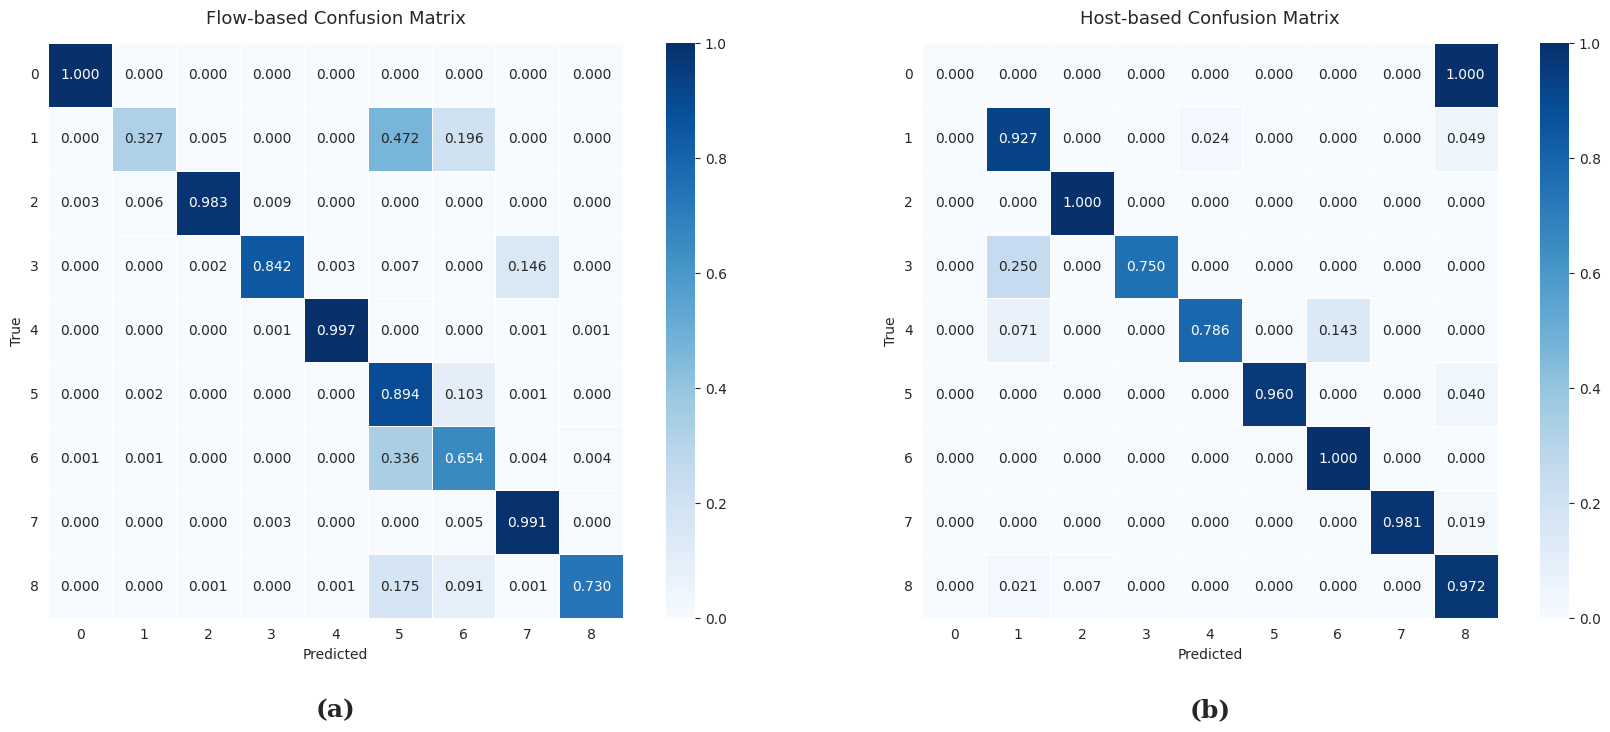

In [14]:
def normalized_confusion_matrix(y_true, y_pred, labels):
    cm = confusion_matrix(y_true, y_pred, labels=labels, normalize="true")
    return np.nan_to_num(cm, nan=0.0)

def plot_confusion_matrices():
    flow_cm = normalized_confusion_matrix(y_test_net, y_pred_net, net_labels)
    host_cm = normalized_confusion_matrix(y_test_sys, y_pred_sys, sys_labels)

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    sns.heatmap(
        flow_cm,
        ax=axes[0],
        annot=True,
        fmt=".3f",
        cmap="Blues",
        vmin=0,
        vmax=1,
        square=True,
        cbar=True,
        xticklabels=net_labels,
        yticklabels=net_labels,
        linewidths=0.5,
        linecolor="white",
    )
    axes[0].set_title("Flow-based Confusion Matrix", fontsize=13, pad=14)
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("True")

    sns.heatmap(
        host_cm,
        ax=axes[1],
        annot=True,
        fmt=".3f",
        cmap="Blues",
        vmin=0,
        vmax=1,
        square=True,
        cbar=True,
        xticklabels=sys_labels,
        yticklabels=sys_labels,
        linewidths=0.5,
        linecolor="white",
    )
    axes[1].set_title("Host-based Confusion Matrix", fontsize=13, pad=14)
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("True")

    for ax in axes:
        ax.tick_params(axis="x", rotation=0)
        ax.tick_params(axis="y", rotation=0)

    axes[0].text(
        0.5, -0.16, "(a)",
        transform=axes[0].transAxes,
        ha="center",
        va="center",
        fontsize=18,
        fontweight="bold",
        family="serif",
    )
    axes[1].text(
        0.5, -0.16, "(b)",
        transform=axes[1].transAxes,
        ha="center",
        va="center",
        fontsize=18,
        fontweight="bold",
        family="serif",
    )

    plt.tight_layout()
    plt.savefig("models/confusion_matrix.png", dpi=200, bbox_inches="tight")
    plt.show()

plot_confusion_matrices()

## Feature Importance

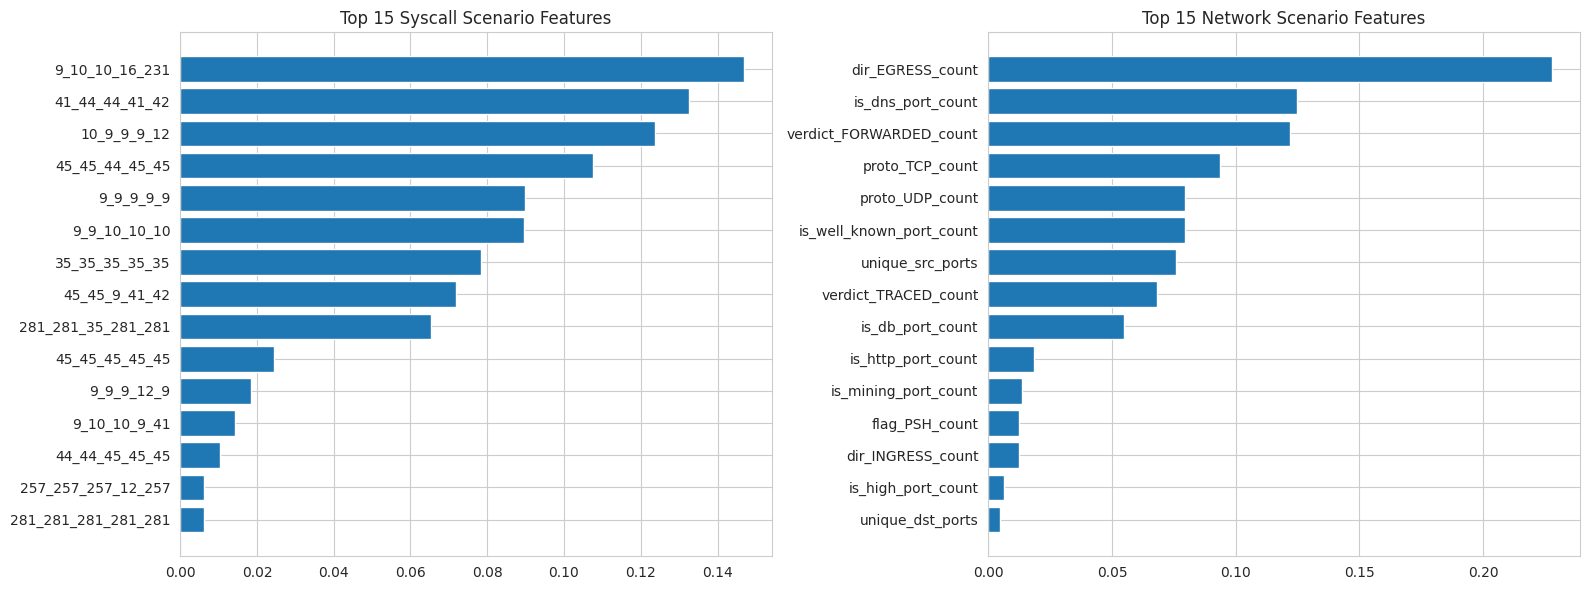

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

def plot_feature_importance(ax, model, columns, title):
    fi = (
        pd.DataFrame({"feature": columns, "importance": model.feature_importances_})
        .sort_values("importance", ascending=False)
        .head(15)
    )
    ax.barh(range(len(fi)), fi["importance"])
    ax.set_yticks(range(len(fi)))
    ax.set_yticklabels(fi["feature"])
    ax.set_title(title)
    ax.invert_yaxis()

plot_feature_importance(axes[0], dt_syscall, X_syscall.columns, "Top 15 Syscall Scenario Features")
plot_feature_importance(axes[1], dt_network, X_network.columns, "Top 15 Network Scenario Features")

plt.tight_layout()
plt.show()


## Visualisasi Decision Tree

## Save Model

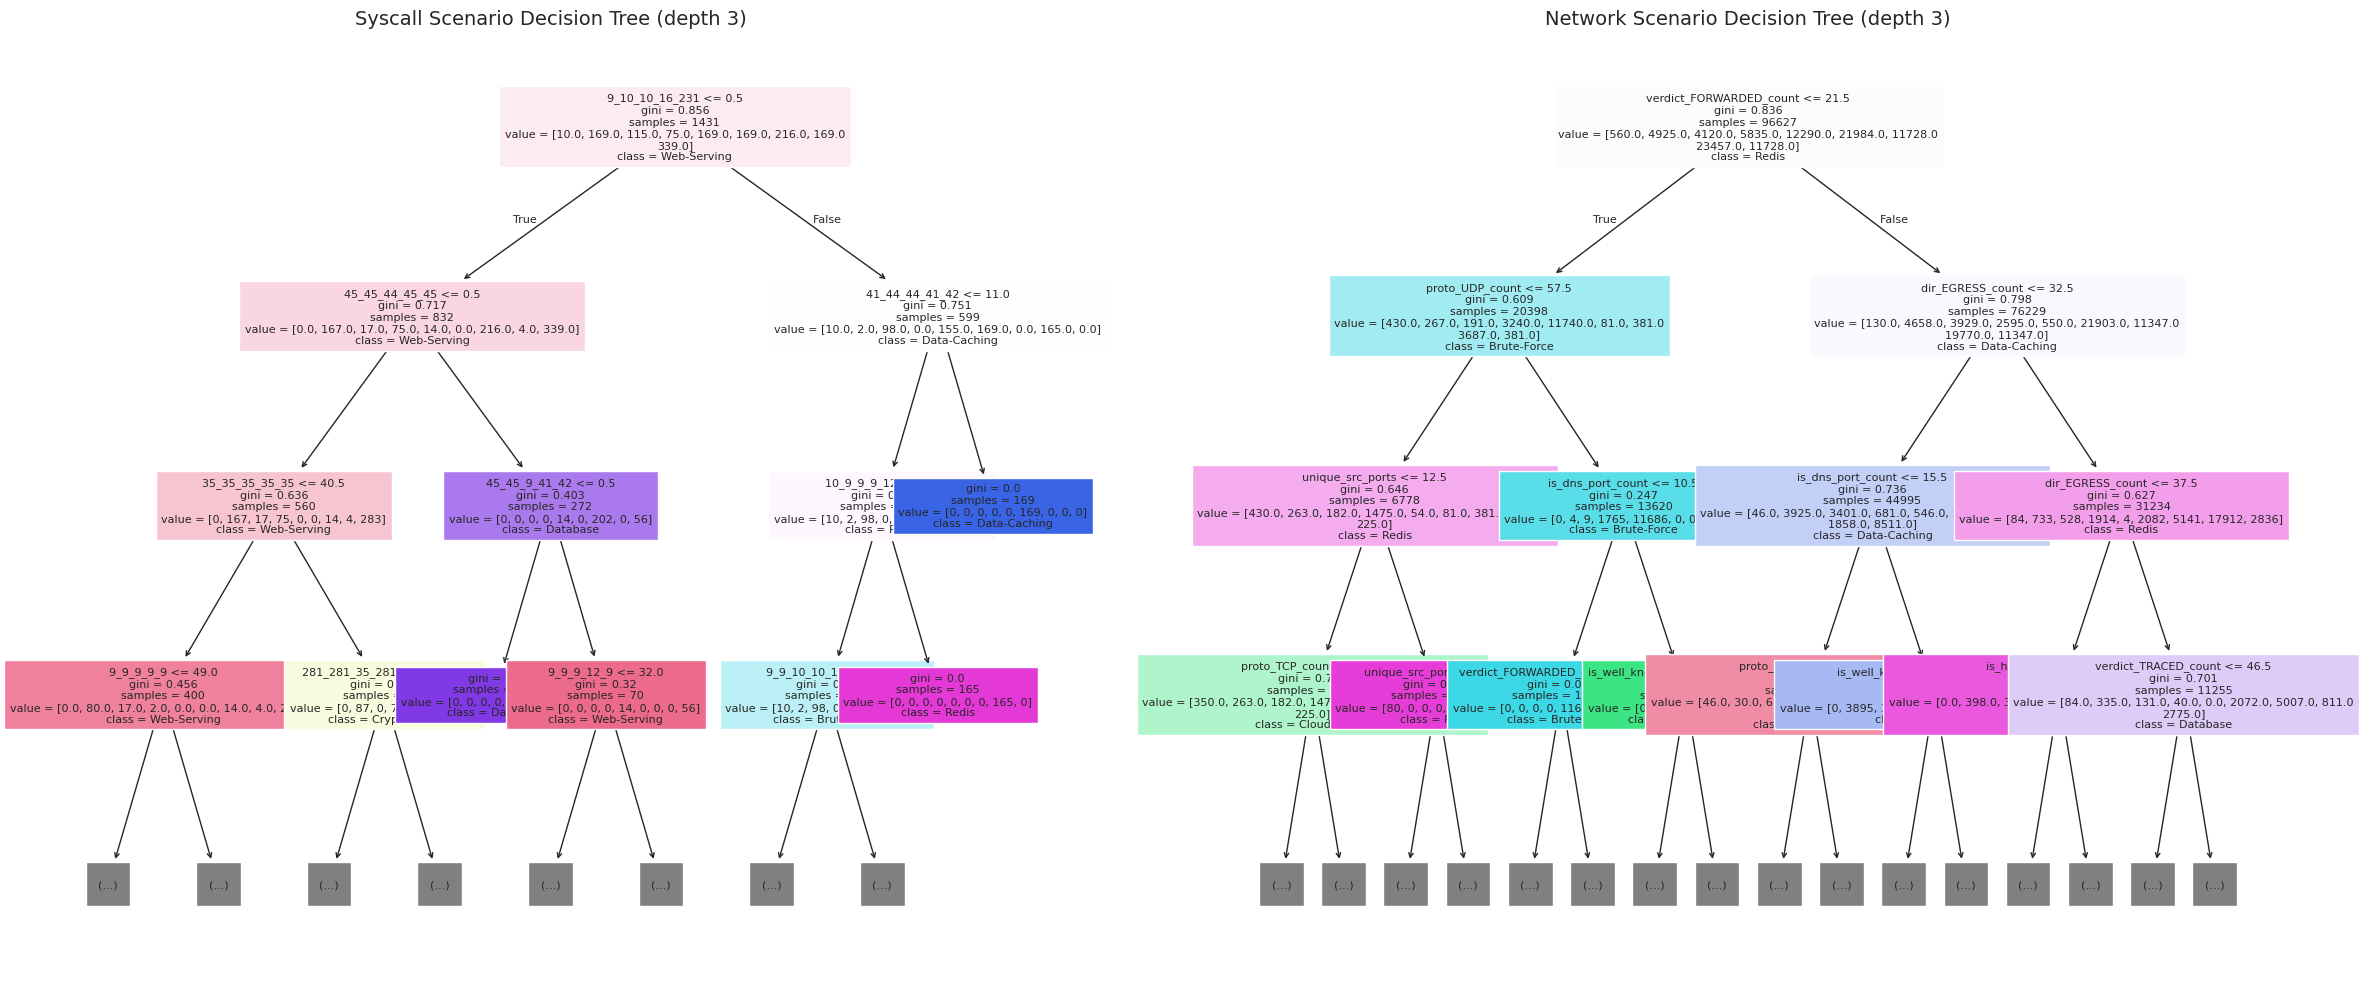

In [16]:
# Decision Tree Visualization (max depth 3 for readability)
fig, axes = plt.subplots(1, 2, figsize=(24, 10))

plot_tree(
    dt_syscall,
    max_depth=3,
    feature_names=X_syscall.columns,
    class_names=[SCENARIO_CLASS_NAMES[i] if 0 <= i < len(SCENARIO_CLASS_NAMES) else str(i) for i in sorted(dt_syscall.classes_)],
    filled=True,
    fontsize=8,
    ax=axes[0],
)
axes[0].set_title("Syscall Scenario Decision Tree (depth 3)", fontsize=14)

plot_tree(
    dt_network,
    max_depth=3,
    feature_names=X_network.columns,
    class_names=[SCENARIO_CLASS_NAMES[i] if 0 <= i < len(SCENARIO_CLASS_NAMES) else str(i) for i in sorted(dt_network.classes_)],
    filled=True,
    fontsize=8,
    ax=axes[1],
)
axes[1].set_title("Network Scenario Decision Tree (depth 3)", fontsize=14)

plt.tight_layout()
plt.savefig("models/decision_tree_visualization.png", dpi=150, bbox_inches="tight")
plt.show()


In [17]:
Path("models").mkdir(exist_ok=True)

# Save scenario models
joblib.dump(dt_syscall, "models/dt_syscall_scenario_model.pkl")
joblib.dump(dt_network, "models/dt_network_scenario_model.pkl")

# Save scaler fitted on syscall training data
from sklearn.preprocessing import StandardScaler
scaler_syscall = StandardScaler().fit(X_train_sys)
joblib.dump(scaler_syscall, "models/scaler_syscall.pkl")

# Backward-compatible aliases for existing loader code.
joblib.dump(dt_syscall, "models/dt_syscall_model.pkl")
joblib.dump(dt_network, "models/dt_network_model.pkl")

joblib.dump(X_syscall.columns.tolist(), "models/feature_names_syscall.pkl")
joblib.dump(X_network.columns.tolist(), "models/feature_names_network.pkl")
joblib.dump(SCENARIO_CLASS_NAMES, "models/scenario_class_names.pkl")

print("Scenario syscall model: models/dt_syscall_scenario_model.pkl")
print("Scenario network model: models/dt_network_scenario_model.pkl")
print("Scaler: models/scaler_syscall.pkl")
print("Feature names and scenario class names saved")


Scenario syscall model: models/dt_syscall_scenario_model.pkl
Scenario network model: models/dt_network_scenario_model.pkl
Scaler: models/scaler_syscall.pkl
Feature names and scenario class names saved
